# COMP47670 — Exam Spring 2025/26

**Student Number**: 25215734

--- 
### Task 1

#### Task 1(a)

In [1]:
import pandas as pd

# Load readings data into dataframe
df_readings = pd.read_csv("Data/readings.csv", parse_dates =["date"])

# Load weather data into dataframe
df_weather = pd.read_csv("Data/weather.csv", parse_dates =["date"])

# Merge both dataframes into a single dataframe on date
df_data = df_weather.merge(df_readings, how = 'inner', on = 'date')

# Shape of the dataframe
print(f"The shape of the merged data is: {df_data.shape}")

# Display last ten rows
df_data.tail(10)

The shape of the merged data is: (365, 11)


,date,temperature,humidity,wind_speed,rainfall,pm10,pm25,no2,so2,co,poor_air_quality
355,2025-12-22,1.2,89.4,12.9,3.5,46.7,25.4,53.2,14.5,1.34,0
356,2025-12-23,3.7,82.1,16.8,1.9,49.6,29.7,38.9,8.6,1.32,1
357,2025-12-24,-0.1,77.4,4.4,3.2,46.3,31.2,47.0,15.5,1.22,1
358,2025-12-25,-2.1,89.4,14.7,0.0,32.7,30.1,29.3,13.7,1.20,0
359,2025-12-26,2.9,82.2,13.7,0.0,42.3,24.0,55.0,14.2,1.14,0
360,2025-12-27,2.6,82.6,11.8,0.0,39.3,28.1,40.7,16.6,1.38,1
361,2025-12-28,2.7,85.3,19.2,0.0,47.1,28.8,47.1,8.5,1.47,1
362,2025-12-29,2.4,90.1,13.7,0.0,31.3,19.5,57.8,7.2,1.35,0
363,2025-12-30,1.0,85.4,14.2,0.1,51.0,31.7,57.1,15.6,1.60,1
364,2025-12-31,2.6,79.1,13.4,0.0,53.9,31.5,44.0,14.5,1.68,1


In [2]:
# Checking the unique values of date
print(f"Date has {df_data["date"].nunique()} unique vales")

# Confirming the data type of date
print(f"Date has a data type of {df_data["date"].dtype}")

Date has 365 unique vales
Date has a data type of datetime64[us]


Date is made the index as all values are unique

All dates are unique so we can make date our index

In [3]:
df_data.isna().sum()

date                0
temperature         0
humidity            0
wind_speed          0
rainfall            0
pm10                0
pm25                0
no2                 0
so2                 0
co                  0
poor_air_quality    0
dtype: int64

In [4]:
df_data = df_data.set_index('date')

#### Task 1(b)

In [5]:
# Checking the data type of wind_speed
df_data["wind_speed"].dtype

dtype('float64')

In [6]:
# grouping function
def wind_group(wind_value):
    if wind_value >= 0 and wind_value < 10:
        return "Low"
    if wind_value >= 10 and wind_value < 20:
        return "Moderate"
    if wind_value >= 20:
        return "High"

# Apply function to wind_speed column   
df_data["wind_speed_cat"] = df_data["wind_speed"].apply(wind_group)

# View dataframe
df_data.head()

,temperature,humidity,wind_speed,rainfall,pm10,pm25,no2,so2,co,poor_air_quality,wind_speed_cat
date,,,,,,,,,,,
2025-01-01,0.5,84.6,17.2,0.4,61.8,32.4,49.3,13.2,1.71,1,Moderate
2025-01-02,5.5,82.0,13.3,1.2,56.5,32.8,44.3,13.9,1.49,1,Moderate
2025-01-03,1.3,83.1,22.5,11.3,59.0,36.9,36.0,16.2,1.74,1,High
2025-01-04,-2.2,95.6,14.9,1.0,41.3,18.5,29.8,13.5,1.55,0,Moderate
2025-01-05,-1.0,76.9,6.0,3.0,34.1,16.4,45.4,12.6,1.35,0,Low


#### Task 1(c)

The are 2 unique poor_air_quality values


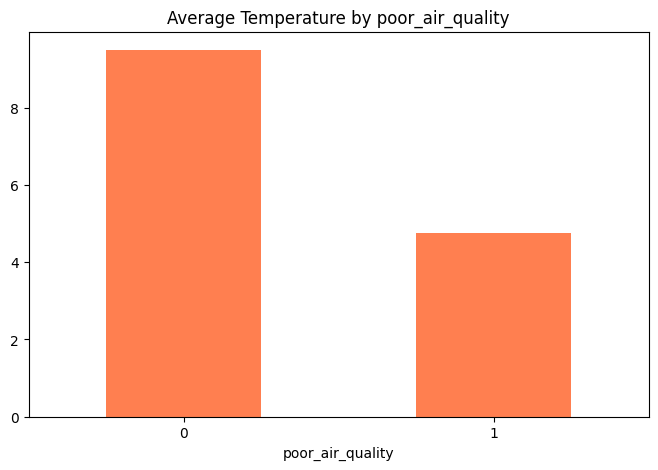

In [7]:
print(f"The are {df_data["poor_air_quality"].nunique()} unique poor_air_quality values")
# it is a categorical data

import matplotlib.pyplot as plt
%matplotlib inline

# Distribution using temperature 
df_data.groupby("poor_air_quality")["temperature"].mean().plot(
    kind="bar",
    figsize=(8,5),
    color="coral"
)

plt.title("Average Temperature by poor_air_quality")
plt.xticks(rotation =0)
plt.show()


Distribution of poor_air_quality


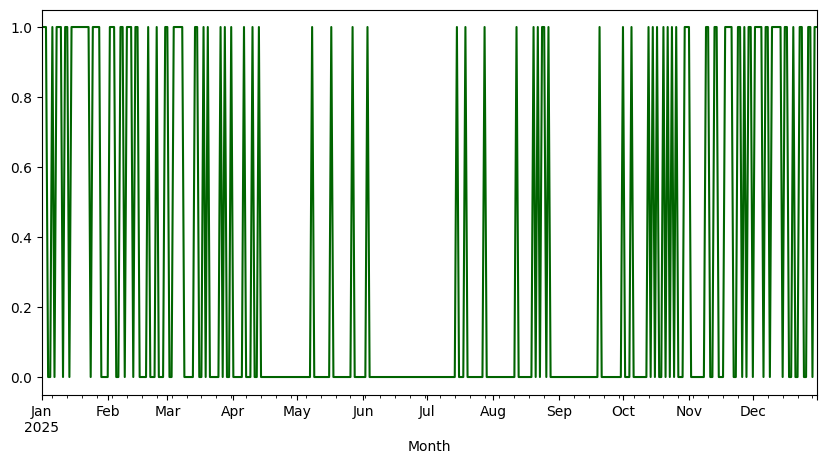

In [8]:
# plot against months when that is the index
ax = df_data["poor_air_quality"].plot(figsize=(10, 5), color="darkgreen")
ax.set_xlabel("Month")
print("Distribution of poor_air_quality")

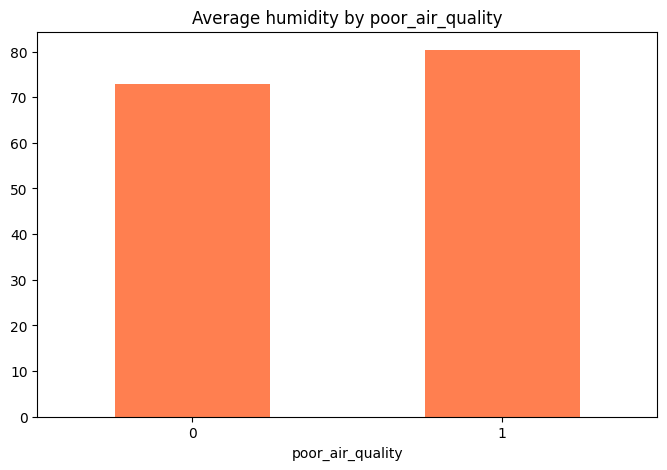

In [9]:
# Distribution using temperature 
df_data.groupby("poor_air_quality")["humidity"].mean().plot(
    kind="bar",
    figsize=(8,5),
    color="coral"
)

plt.title("Average humidity by poor_air_quality")
plt.xticks(rotation =0)
plt.show()

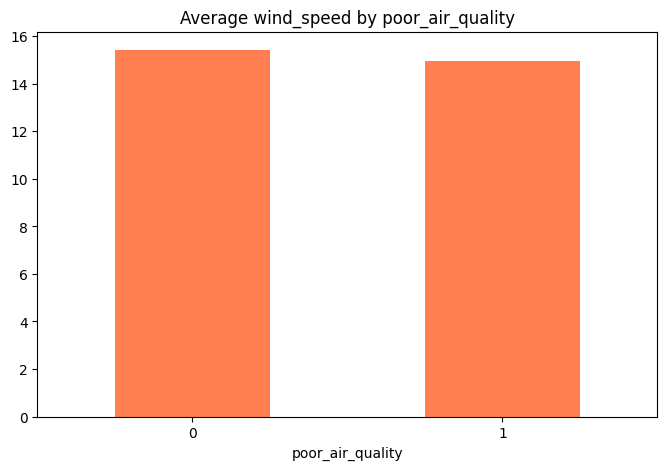

In [10]:
# Distribution using wind_speed 
df_data.groupby("poor_air_quality")["wind_speed"].mean().plot(
    kind="bar",
    figsize=(8,5),
    color="coral"
)

plt.title("Average wind_speed by poor_air_quality")
plt.xticks(rotation =0)
plt.show()

--- 
### Task 2

#### Task 2(a)

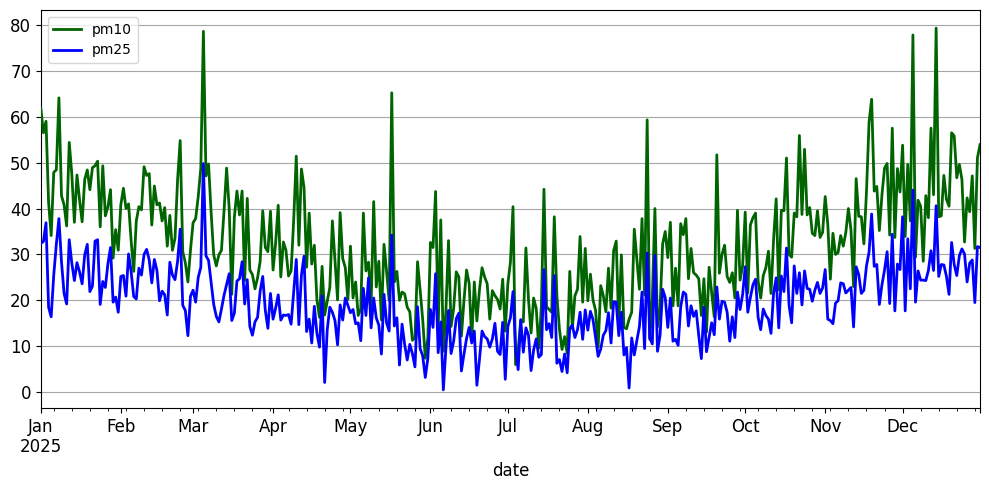

In [11]:
ax = df_data["pm10"].plot(figsize=(10, 5), lw=2, color="darkgreen", fontsize=12, zorder=3)
ax = df_data["pm25"].plot(figsize=(10, 5), lw=2, color="blue", fontsize=12, zorder=3)
ax.grid(axis="y", color="gray", alpha=0.7)
#ax.set_ylabel("Temperature", fontsize=12)
ax.set_xlabel("date", fontsize=12)
plt.tight_layout()
plt.legend()

#### Task 2(b)

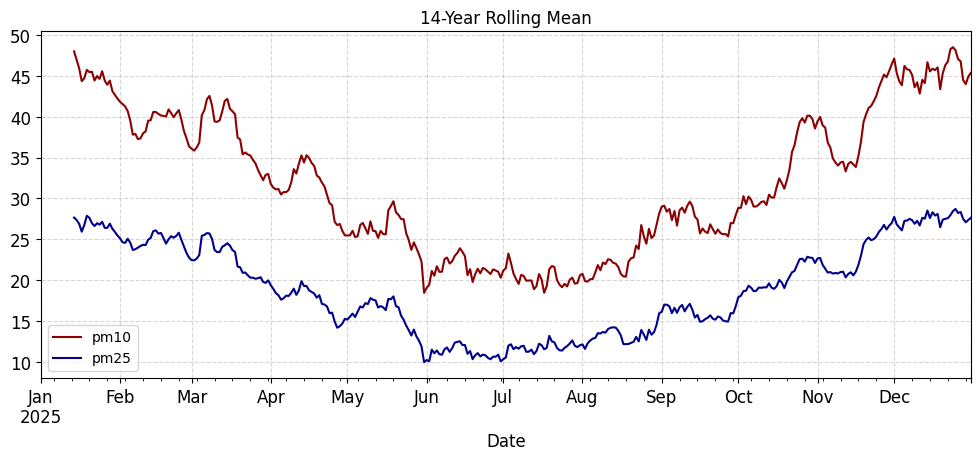

In [12]:
# calculate and plot 10 year rolling average
rm_10 = df_data["pm10"].rolling(14).mean()
rm_25 = df_data["pm25"].rolling(14).mean()

# plot the rolling mean
ax = rm_10.plot(figsize=(12, 4.5), fontsize=12, color="darkred")
ax = rm_25.plot(figsize=(12, 4.5), fontsize=12, color="darkblue")
# set axis labels and title
ax.set_xlabel("Date", fontsize=12)
#ax.set_ylabel("Production", fontsize=12)
ax.set_title("14-Year Rolling Mean", fontsize=12)
# add gridlines
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

#### Task 2(c)

From task 2a before smoothing the graph gives us more details 

However after smoothing in b the details are reduced 

One thing however is the same pm10 has higher values that pm25 
- pm10: level of larger airborne particles in the air (µg/m³)
- pm25: level of smaller airborne particles in the air (µg/m³)

That means the level of larger airborne particles in the air is always high throughout the year 

Both experience dips aroung the same period of May to September

--- 
### Task 3

#### Task 3(a)

In [13]:
from sklearn.model_selection import train_test_split

# One hot endcoding since it is a categorical data
target = pd.get_dummies(df_data["poor_air_quality"], prefix='', prefix_sep='', drop_first=True, dtype=int)

features = pd.get_dummies(df_data.drop("poor_air_quality", axis = 1), prefix='', prefix_sep='', drop_first=True, dtype=int)

# Train/test split 
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Class balance
print(f"Our training data, x has shape {X_train.shape}")
print(f"Our training data, y has shape {y_train.shape}")
print(f"Our test data, x has shape {X_test.shape}")
print(f"Our test data, y has shape {y_test.shape}")


Our training data, x has shape (255, 11)
Our training data, y has shape (255, 1)
Our test data, x has shape (110, 11)
Our test data, y has shape (110, 1)


#### Task 3(b)

Accuracy: 0.8545454545454545


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


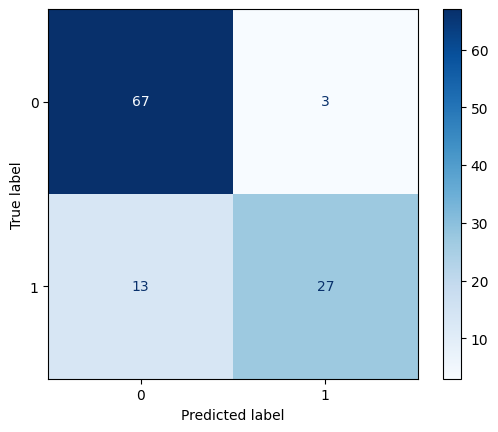

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import  accuracy_score

# KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
predicted_knn = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predicted_knn))


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix
cm_knn = confusion_matrix(y_test, predicted_knn)

# Plotting confusion matrix
labels = knn.classes_
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=labels)
disp.plot(cmap="Blues")


Accuracy: 0.9


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


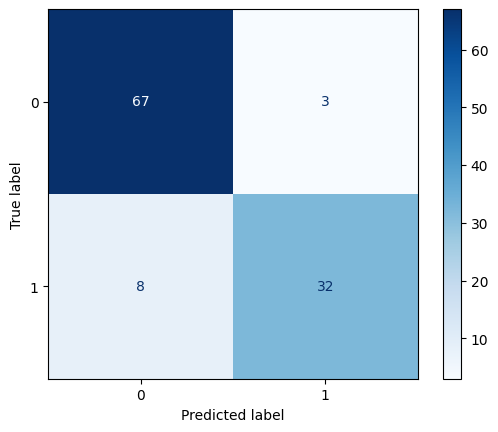

In [15]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression model
model = LogisticRegression(C=1e42, solver='liblinear')

# Train model
model.fit(X_train,y_train)

# Get predictions for model
predicted_lr = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predicted_lr))

# Confusion matrix
cm_lr = confusion_matrix(y_test, predicted_lr)

# Plotting confusion matrix
labels = knn.classes_
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=labels)
disp.plot(cmap="Blues")


#### Task 3(c)

From both results we realised that our logistic regression model gives us a higher accuracy 

Also our true negative(67) and false positve(3) rates are the same on both models, meaning both model performed quite well on our negatives however with positives the logistic regression model did better giving it a higher accuracy score